In [1]:
import pandas as pd

file = '../Scenario_Analysis.xlsx'
df = pd.read_excel(file, sheet_name='MethanolLDC')
df = df.set_index(df.columns[0])

# 1. global maximum across all scenarios and hours
global_max = df.values.max()

# 2. normalize
df_norm = df / global_max
df_norm

,T0001,T0002,T0003,T0004,T0005,T0006,T0007,T0008,T0009,T0010,...,T8751,T8752,T8753,T8754,T8755,T8756,T8757,T8758,T8759,T8760
Scenario,,,,,,,,,,,,,,,,,,,,,
Baseline,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
NoStorageCO2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
NoStorageALL,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
H2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
BioFixed,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
CO2Trans,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [2]:
import numpy as np
import pandas as pd

# Sort each row descending (axis=1), then reverse so highest is first
ldc_values = np.sort(df_norm.values, axis=1)[:, ::-1]

df_ldc = pd.DataFrame(
    ldc_values,
    index=df_norm.index,
    columns=range(1, df_norm.shape[1] + 1)   # 1...8760
)
df_ldc

,1,2,3,4,5,6,7,8,9,10,...,8751,8752,8753,8754,8755,8756,8757,8758,8759,8760
Scenario,,,,,,,,,,,,,,,,,,,,,
Baseline,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NoStorageCO2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NoStorageALL,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.4,0.4,0.4,0.4,0.4,0.4,0.4,0.4,0.4,0.4
H2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
BioFixed,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CO2Trans,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
import matplotlib.pyplot as plt

def plot_ldc(df_ldc, scenarios, scenario_colors=None):
    
    if scenario_colors is None:
        scenario_colors = {}

    fig, ax = plt.subplots(figsize=(12,5))

    x = df_ldc.columns  # Hour ranks 1..8760

    for scen in scenarios:
        ax.plot(
            x,
            df_ldc.loc[scen],
            linewidth=2,
            label=scen,
            color=scenario_colors.get(scen, None)
        )

    ax.set_title("Load Duration Curves (Normalized)")

    # --- NEW: fixed axis limits ---
    # ax.set_ylim(0, 1)
    ax.set_xlim(0, 8760)

    # Grid and legend
    ax.grid(axis='both', alpha=0.5)
    ax.set_axisbelow(True)

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=len(scenarios),
        frameon=False
    )

    fig.tight_layout()
    return fig


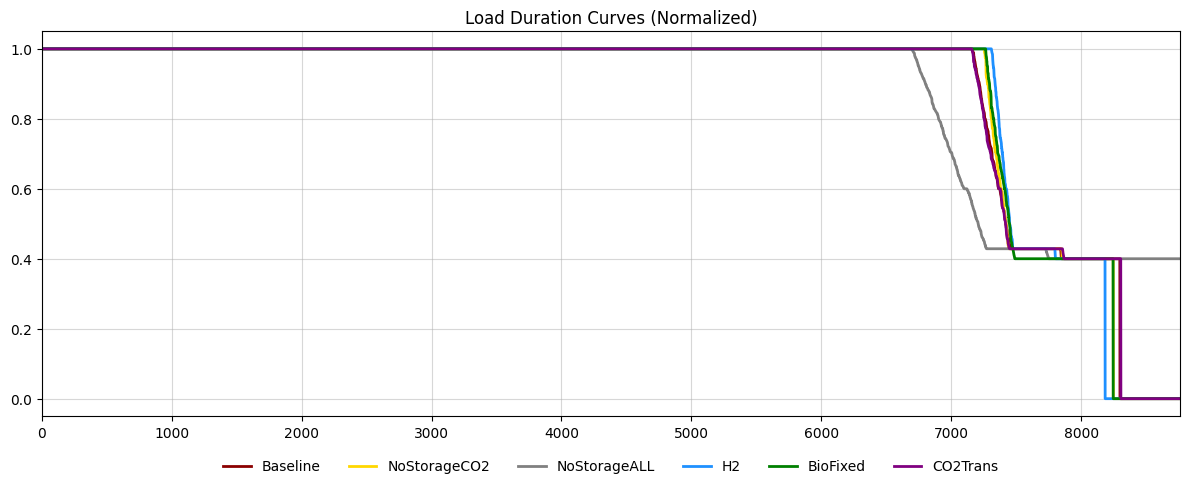

In [4]:
scenario_colors = {
    "Baseline":  "darkred",
    "NoStorageCO2": "gold",
    "NoStorageALL": "gray",
    "H2":        "dodgerblue",
    "BioFixed":  "green",
    "CO2Trans": "purple"
}

scenarios = ["Baseline", "NoStorageCO2", "NoStorageALL", "H2", "BioFixed", "CO2Trans"]

fig = plot_ldc(df_ldc, scenarios, scenario_colors)

fig.savefig("LDCMethanol.pdf", format="pdf", bbox_inches="tight")
plt.show()